Number of observations: 500


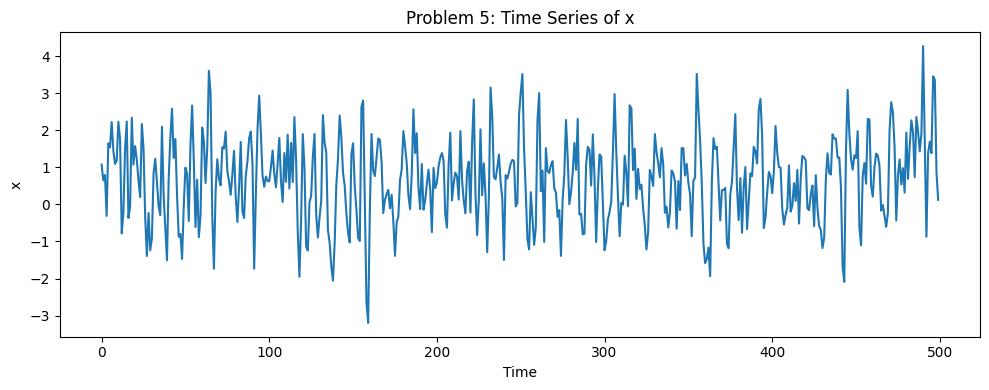

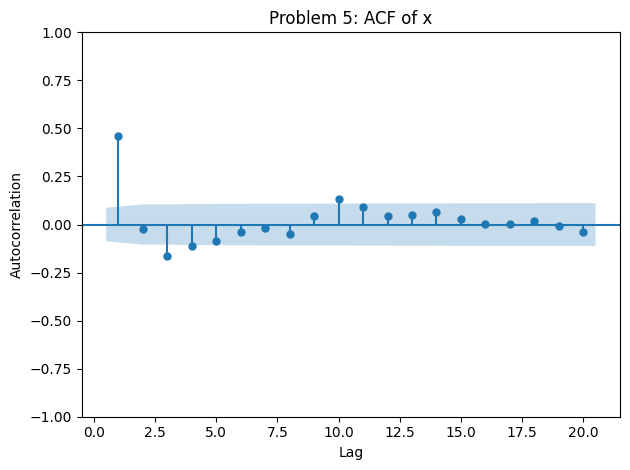

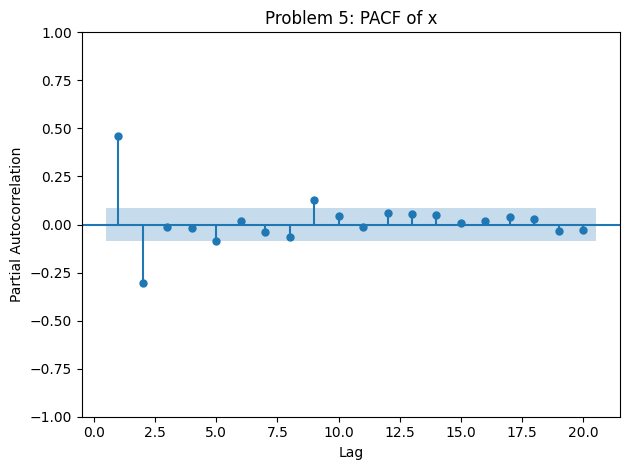

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data = pd.read_csv("problem5.csv")
x = data["x"].dropna()

print("Number of observations:", len(x))


# ------------------------------------------------------------
# 2. Plot the original time series
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(x)

plt.title("Problem 5: Time Series of x")
plt.xlabel("Time")
plt.ylabel("x")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Plot the sample ACF
# ------------------------------------------------------------
# statsmodels automatically draws the approximate 95%
# significance band around zero.

plot_acf(
    x,
    lags=20,
    alpha=0.05,
    zero=False
)

plt.title("Problem 5: ACF of x")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Plot the sample PACF
# ------------------------------------------------------------

plot_pacf(
    x,
    lags=20,
    alpha=0.05,
    zero=False,
    method="ywm"
)

plt.title("Problem 5: PACF of x")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

In [7]:
from statsmodels.tsa.arima.model import ARIMA
n = len(x)
#  ------------------------------------------------------------
# 2. Define a function for AICc
# ------------------------------------------------------------
# AICc = AIC + 2*k*(k+1)/(n-k-1)
#
# k = total number of estimated parameters.
#
# statsmodels reports all estimated parameters in model.params,
# including:
#   - intercept / constant
#   - AR or MA coefficients
#   - innovation variance sigma^2
#
# Therefore, len(model.params) gives k directly.
# ------------------------------------------------------------

def calculate_aicc(model, n):

    k = len(model.params)

    aic = model.aic

    correction = (2 * k * (k + 1)) / (n - k - 1)

    aicc = aic + correction

    return aicc, k


# ------------------------------------------------------------
# 3. Fit all candidate models
# ------------------------------------------------------------

results = []

candidate_models = [
    ("AR(1)", (1, 0, 0)),
    ("AR(2)", (2, 0, 0)),
    ("AR(3)", (3, 0, 0)),
    ("MA(1)", (0, 0, 1)),
    ("MA(2)", (0, 0, 2)),
    ("MA(3)", (0, 0, 3))
]


for model_name, order in candidate_models:

    # Fit ARIMA(p,0,q).
    # d = 0 because the series appears stationary and
    # no differencing is being used.
    model = ARIMA(
        x,
        order=order,
        trend="c"
    ).fit()

    # Calculate AICc manually
    aicc, k = calculate_aicc(model, n)

    # Store relevant outputs
    results.append({
        "Model": model_name,
        "LogLik": model.llf,
        "k": k,
        "AIC": model.aic,
        "AICc": aicc,
        "Parameters": model.params.to_dict()
    })


# ------------------------------------------------------------
# 4. Put results into a table
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

# Sort models from lowest (best) AICc to highest
results_df = results_df.sort_values("AICc").reset_index(drop=True)

print("\nProblem 5(c): Model Comparison")

print(
    results_df[
        ["Model", "LogLik", "k", "AIC", "AICc"]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 5. Print parameter estimates for every model
# ------------------------------------------------------------

print("\nParameter Estimates")
for _, row in results_df.iterrows():

    print(f"\n{row['Model']}")
    
    for parameter, value in row["Parameters"].items():
        print(f"  {parameter}: {value:.6f}")


# ------------------------------------------------------------
# 6. Identify the model with the lowest AICc
# ------------------------------------------------------------

best_model = results_df.iloc[0]
print("Best model by AICc:")
print(f"Model: {best_model['Model']}")
print(f"AICc:  {best_model['AICc']:.6f}")


Problem 5(c): Model Comparison
Model      LogLik  k         AIC        AICc
AR(2) -682.178751  4 1372.357502 1372.438310
MA(3) -681.997534  5 1373.995068 1374.116525
AR(3) -682.110877  5 1374.221753 1374.343211
MA(2) -686.575406  4 1381.150811 1381.231619
MA(1) -691.517947  3 1389.035894 1389.084281
AR(1) -706.269286  3 1418.538572 1418.586959

Parameter Estimates

AR(2)
  const: 0.670607
  ar.L1: 0.601201
  ar.L2: -0.302638
  sigma2: 0.895802

MA(3)
  const: 0.670895
  ma.L1: 0.593080
  ma.L2: 0.064825
  ma.L3: -0.155454
  sigma2: 0.895105

AR(3)
  const: 0.670484
  ar.L1: 0.596203
  ar.L2: -0.292690
  ar.L3: -0.016542
  sigma2: 0.895558

MA(2)
  const: 0.670989
  ma.L1: 0.631356
  ma.L2: 0.161482
  sigma2: 0.911749

MA(1)
  const: 0.671300
  ma.L1: 0.529601
  sigma2: 0.930102

AR(1)
  const: 0.670664
  ar.L1: 0.461053
  sigma2: 0.986801
Best model by AICc:
Model: AR(2)
AICc:  1372.438310
